In [2]:
!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 747.1 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218907 sha256=fb95484c76fcc370b0223adffb7850a694eac406f3e935b645b80096052c9f24
  Stored in directory: /root/.cache/pip/wheels/69/00/ac/f7fa862c34b0e2ef320175100c233377b4c558944f12474cf0
Successfully built pandas_ta


In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_ta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [19]:
data = yf.download("GOOGL",period= "5y")

[*********************100%%**********************]  1 of 1 completed


In [20]:
data.tail(10)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-06-07,177.050003,177.869995,174.300003,174.460007,174.260010,19661400
2024-06-10,174.970001,177.059998,172.759995,175.009995,175.009995,23779200
2024-06-11,176.220001,176.839996,173.770004,176.619995,176.619995,21540600
2024-06-12,178.250000,180.410004,176.110001,177.789993,177.789993,27864700
2024-06-13,176.110001,176.740005,174.880005,175.160004,175.160004,20913300
2024-06-14,174.220001,177.059998,174.149994,176.789993,176.789993,18063600
2024-06-17,175.460007,178.360001,174.809998,177.240005,177.240005,19618500
2024-06-18,177.139999,177.389999,174.100006,175.089996,175.089996,21869900
2024-06-20,175.369995,177.289993,174.990005,176.300003,176.300003,20160100


In [21]:
data['PVI'] = pandas_ta.pvi(close=data['Adj Close'],volume = data['Volume'],length=20)

In [22]:
data['RSI'] = pandas_ta.rsi(close=data['Adj Close'], length=20)
data['RSI_lag'] = data['RSI'].shift()
data= data.dropna()
data.head()

,Open,High,Low,Close,Adj Close,Volume,PVI,RSI,RSI_lag
Date,,,,,,,,,
2019-07-24,56.631001,57.272999,56.425499,56.986500,56.921173,27192000,1004.795050,56.262294,60.659732
2019-07-25,56.947498,57.179501,56.185501,56.797001,56.731892,54762000,1009.943534,54.372278,56.262294
2019-07-26,61.400002,63.419498,61.400002,62.261002,62.189629,121216000,1025.602583,77.407524,54.372278
2019-07-29,62.125000,62.449501,61.509998,62.091999,62.020817,41382000,1025.602583,76.155729,77.407524
2019-07-30,61.349998,61.845501,61.265999,61.400002,61.329613,28616000,1025.602583,71.193570,76.155729


In [23]:
data['Signal_1'] = data['PVI'].diff().apply(lambda x:1 if x>1 else(-1 if x<1 else np.nan))
data['Signal_2'] = data.apply(lambda x: 1 if (x['RSI_lag']<50) & (x['RSI']>50)
else (-1 if (x['RSI_lag']>50) & (x['RSI']<50) else np.nan), axis=1)

In [24]:
data['Position'] = data.apply(lambda x:'Buy' if (x['Signal_1'] + x['Signal_2']==2)
else 'Sell' if (x['Signal_1'] + x['Signal_2']==-2) else np.nan, axis=1)


In [25]:
data2 = data[data['Position'].notna()]
data2.tail(5)

,Open,High,Low,Close,Adj Close,Volume,PVI,RSI,RSI_lag,Signal_1,Signal_2,Position
Date,,,,,,,,,,,,
2023-12-11,132.380005,133.339996,131.360001,133.289993,133.137192,31138000,1758.199992,49.973625,52.380081,-1.0,-1.0,Sell
2024-01-05,136.750000,137.160004,135.149994,135.729996,135.574402,22506000,1777.347274,49.805829,51.000155,-1.0,-1.0,Sell
2024-02-02,139.259995,142.619995,136.500000,142.380005,142.216782,62470600,1845.842078,50.770285,49.101634,1.0,1.0,Buy
2024-02-15,143.139999,143.520004,140.460007,142.770004,142.606339,37590700,1852.077507,49.373800,54.167768,-1.0,-1.0,Sell
2024-02-26,142.139999,142.440002,137.389999,137.570007,137.412308,53641800,1839.370908,42.730406,51.454260,-1.0,-1.0,Sell


In [26]:
def strategy_implementation(data, investment):
  equity = investment
  pos = 0
  buy=[]
  sell = []
  for i in range(len(data['Position'])):
    if data['Position'][i] == 'Sell':
      sell.append(1)
      pos -= 1
      equity += data['Adj Close'][i]
      print(f"SELL at price {data['Adj Close'][i]:.2f}. Equity: {equity:.2f}.")
    elif data['Position'][i] == 'Buy':
      buy.append(1)
      pos += 1
      equity -= data['Adj Close'][i]
      print(f"BUY at price {data['Adj Close'][i]:.2f}. Equity: {equity:.2f}.")
  #Make sure no positions held at the end of the period
  if pos>1:
    stocks_sold = pos
    equity += stocks_sold * data['Adj Close'][i]
    print(f"SELL at price {data['Adj Close'][i]:.2f}. Equity: {equity:.2f}.Stocks sold to close existing position {stocks_sold}.")
    sell.append(1)
  elif pos<1:
    stocks_bought = abs(pos)
    equity -= stocks_bought * data['Adj Close'][i]
    print(f"BUY at price {data['Adj Close'][i]:.2f}. Stocks bought to close existing position {stocks_bought}.")
    buy.append(1)
    print('')
    print(f"Number of Trades {len(buy)+len(sell)}.")
    print(f"Number of Buy trades {len(buy)}.")
    print(f"Number of Sell trades {len(sell)}.")



In [27]:
strategy_implementation(data,0)

SELL at price 57.61. Equity: 57.61.
SELL at price 58.83. Equity: 116.44.
SELL at price 59.44. Equity: 175.88.
SELL at price 70.91. Equity: 246.79.
BUY at price 63.19. Equity: 183.60.
BUY at price 67.03. Equity: 116.57.
SELL at price 68.05. Equity: 184.62.
SELL at price 73.58. Equity: 258.20.
SELL at price 73.94. Equity: 332.14.
SELL at price 76.09. Equity: 408.23.
BUY at price 77.75. Equity: 330.48.
SELL at price 85.91. Equity: 416.39.
SELL at price 86.21. Equity: 502.60.
SELL at price 86.05. Equity: 588.64.
SELL at price 86.77. Equity: 675.42.
SELL at price 86.45. Equity: 761.86.
BUY at price 89.12. Equity: 672.74.
SELL at price 109.89. Equity: 782.63.
SELL at price 135.67. Equity: 918.30.
SELL at price 136.29. Equity: 1054.60.
SELL at price 137.41. Equity: 1192.00.
BUY at price 139.15. Equity: 1052.86.
SELL at price 142.02. Equity: 1194.88.
SELL at price 141.73. Equity: 1336.61.
SELL at price 143.74. Equity: 1480.35.
SELL at price 144.28. Equity: 1624.63.
BUY at price 147.83. Equity:

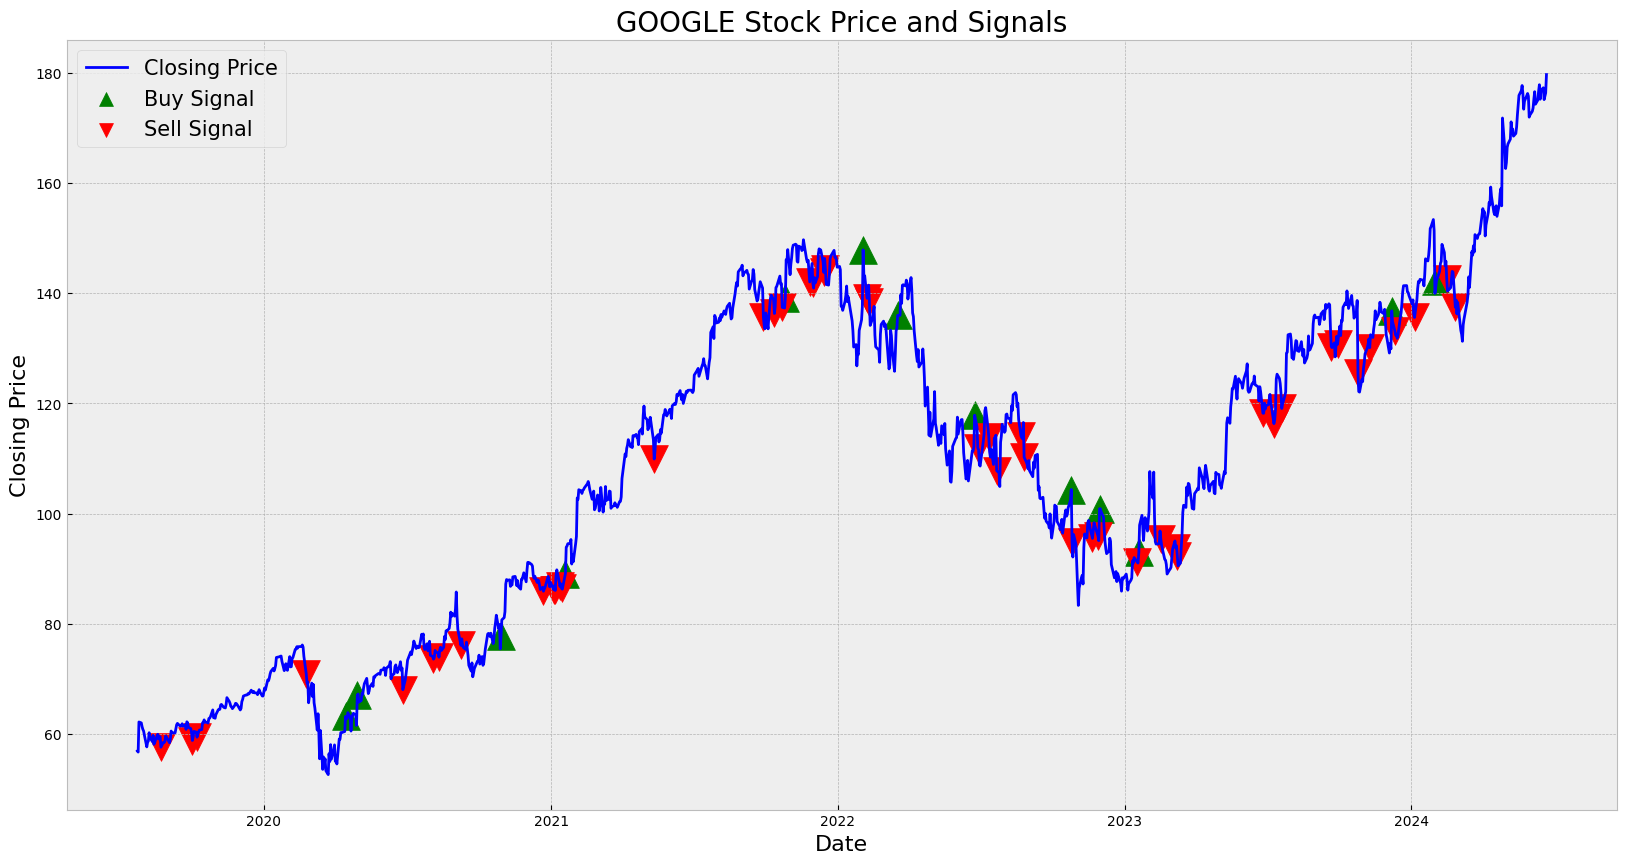

In [28]:
plt.figure(figsize=(20,10))
plt.style.use("bmh")
plt.plot(data['Adj Close'], label='Closing Price', linestyle="-", linewidth=2,color='blue')
buy = data2[data2['Position']=='Buy']['Adj Close']
plt.scatter(buy.index, buy, marker="^", color='g', s=400, label='Buy Signal')
sell = data2[data2['Position']=='Sell']['Adj Close']
plt.scatter(sell.index, sell, marker="v", color='r', s=400, label='Sell Signal')
plt.title("GOOGLE Stock Price and Signals", fontsize=20)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Closing Price", fontsize=16)
plt.legend(loc='upper left', markerscale=0.5,fontsize=15);